<a href="https://colab.research.google.com/github/FishyFoshy/COMP3608-Project/blob/main/Dataset_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Cleaning of Dataset 3

In [21]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Load datasets
df3 = pd.read_csv('Dataset 3.csv')

# Drops all unnecessary columns
df3 = df3.drop(columns=['id', 'date', 'yr_renovated', 'zipcode', 'sqft_living15', 'sqft_lot15'])

# Drops all with null values
df3.dropna(inplace=True)

# Remove the top 1% highest prices to reduce high-end outliers before log-transform

df3_outr = df3.copy()
upper_quantile = df3_outr['price'].quantile(0.99)
df3_outr = df3_outr[df3_outr['price'] <= upper_quantile]


# Apply log transform to the target
df3['price'] = np.log(df3['price'])

# Create a copy of df3 for Linear Regression before feature engineering
df3lr = df3.copy()

# Apply location-based feature engineering to df3lr only (for Linear Regression)
df3lr['lat_lon_interaction'] = df3lr['lat'] * df3lr['long']
center_lat = df3lr['lat'].mean()
center_lon = df3lr['long'].mean()
df3lr['dist_to_center'] = np.sqrt((df3lr['lat'] - center_lat)**2 + (df3lr['long'] - center_lon)**2)
df3lr = df3lr.drop(columns=['lat', 'long'])  # Drop original lat/lon to avoid multicollinearity

# Separates non numerical columns from numerical ones
non_numerical_columns = ['price']

# Process df3lr (for Linear Regression): scale and encode
numerical_features_lr = [col for col in df3lr.columns if col not in non_numerical_columns]
scaler_lr = StandardScaler()
df3lr[numerical_features_lr] = scaler_lr.fit_transform(df3lr[numerical_features_lr])
categorical_cols_lr = df3lr.select_dtypes(include='object').columns
df3lr = pd.get_dummies(df3lr, columns=categorical_cols_lr, drop_first=True)

target_column = 'price'
x_lr = df3lr[[col for col in df3lr.columns if col != target_column]].copy()
y_lr = df3lr[target_column].copy()
x_train_lr, x_test_lr, y_train_lr, y_test_lr = train_test_split(x_lr, y_lr, test_size=0.2, random_state=42)

# Process df3 (for tree models: Random Forest, XGBoost): keep raw lat/lon, scale and encode
numerical_features = [col for col in df3.columns if col not in non_numerical_columns]
scaler = StandardScaler()
df3[numerical_features] = scaler.fit_transform(df3[numerical_features])
categorical_cols_to_encode = df3.select_dtypes(include='object').columns
df3 = pd.get_dummies(df3, columns=categorical_cols_to_encode, drop_first=True)

features = [col for col in df3.columns if col != target_column]
x = df3[features].copy()
y = df3[target_column].copy()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("=" * 60)
print("DATASET 3: Dataset 3.csv")
print("=" * 60)
print("\nFirst 10 rows:")
display(df3.head(10))
print("\nData types:")
print(df3.dtypes)
print("\nMissing values:")
print(df3.isnull().sum())
print("\nTarget variable (price) statistics:")
print(df3['price'].describe())

DATASET 3: Dataset 3.csv

First 10 rows:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,lat,long
0,12.309982,-0.398737,-1.447464,-0.979835,-0.228321,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.734708,-0.658681,-0.544898,-0.352572,-0.306079
1,13.195614,-0.398737,0.175607,0.533634,-0.189885,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.460841,0.245141,-0.681079,1.161568,-0.746341
2,12.100712,-1.473959,-1.447464,-1.426254,-0.123298,-0.915427,-0.087173,-0.305759,-0.629187,-1.409587,-1.229834,-0.658681,-1.293892,1.283537,-0.135655
3,13.311329,0.676485,1.149449,-0.130550,-0.244014,-0.915427,-0.087173,-0.305759,2.444294,-0.558836,-0.891699,1.397515,-0.204446,-0.283288,-1.271816
4,13.142166,-0.398737,-0.149007,-0.435422,-0.169653,-0.915427,-0.087173,-0.305759,-0.629187,0.291916,-0.130895,-0.658681,0.544548,0.409550,1.199335
5,14.018451,0.676485,3.097133,3.636791,2.096185,-0.915427,-0.087173,-0.305759,-0.629187,2.844170,2.537955,2.798440,1.021181,0.693181,1.483375
6,12.458775,-0.398737,0.175607,-0.397313,-0.200098,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,-0.088628,-0.658681,0.816910,-1.806810,-0.803149
7,12.583995,-0.398737,-0.798235,-1.110494,-0.130276,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.879623,-0.658681,-0.272536,-1.086547,-0.717937
8,12.343658,-0.398737,-1.447464,-0.326539,-0.184381,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.891699,0.990795,-0.374672,-0.344633,-0.874160
9,12.685408,-0.398737,0.500221,-0.206768,-0.206351,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.122706,-0.658681,1.089271,-1.383168,1.298749



Data types:
price            float64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition        float64
grade            float64
sqft_above       float64
sqft_basement    float64
yr_built         float64
lat              float64
long             float64
dtype: object

Missing values:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
lat              0
long             0
dtype: int64

Target variable (price) statistics:
count    21613.000000
mean        13.047817
std          0.526685
min         11.225243
25%         12.682152
50%         13.017003
75%         13.377006
max         15.856731
Name: price, dtype: float64


# Linear Regression for Dataset 3

In [22]:
from sklearn.model_selection import cross_val_score, KFold,cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,root_mean_squared_error,get_scorer_names, make_scorer
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn import metrics

model = LinearRegression()
model.fit(x_train,y_train)
predictions = model.predict(x_test)



----Log Space Metrics---
RMSE: $0.26
MAE: $0.20
r2: 0.7602

--- Real-Space Metrics ---
RMSE: $330,922.02
MAE: $120,547.23
r2: 0.2756

--- Cross Validated Scores ---
RMSE: $208,690.58
MAE: $112,274.46
r2: 0.6569



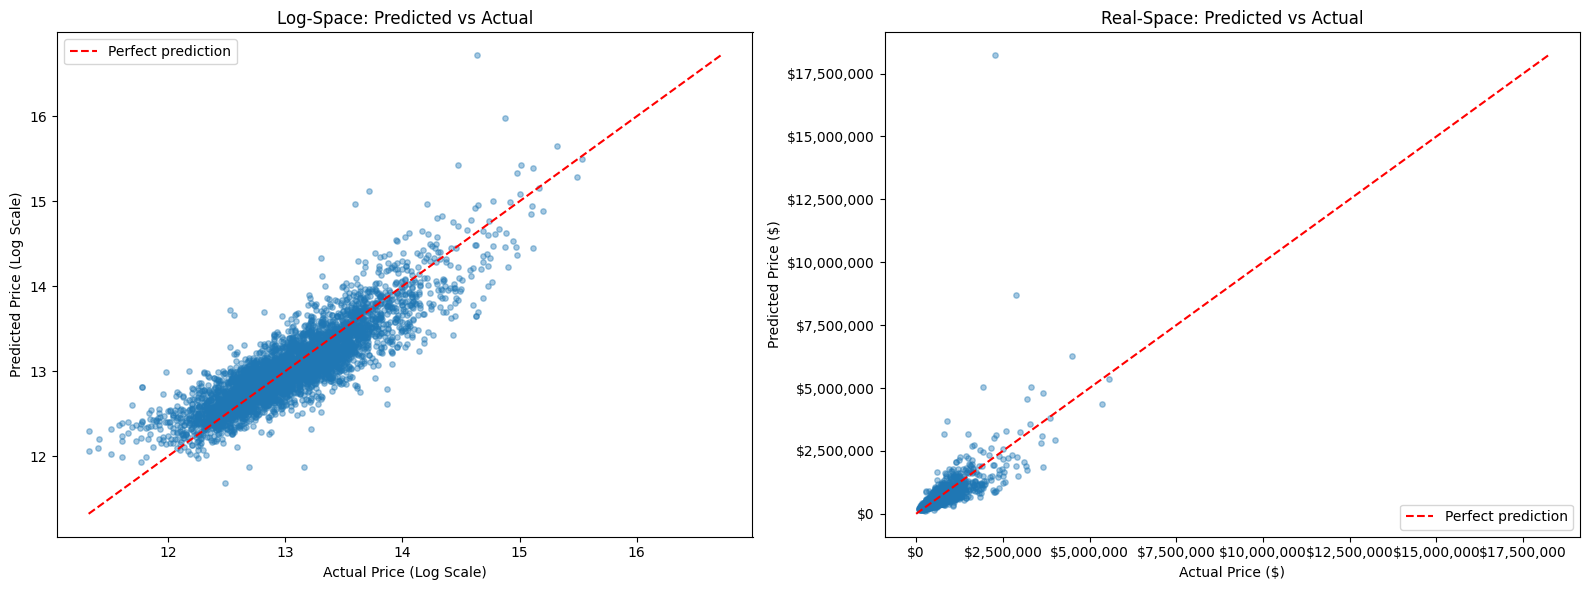

In [ ]:
y_test_real = np.expm1(y_test)
predictions_real = np.expm1(predictions)

print("----Log Space Metrics---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test, predictions):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test, predictions):,.2f}")
print(f"r2: {metrics.r2_score(y_test, predictions):.4f}\n")

print("--- Real-Space Metrics ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_real, predictions_real):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test_real, predictions_real):,.2f}")
print(f"r2: {metrics.r2_score(y_test_real, predictions_real):.4f}\n")

from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse the log transformation to its original scale
def rmse_original_scale(y_true, y_pred):
    y_true_original = np.expm1(y_true)
    y_pred_original = np.expm1(y_pred)
    return np.sqrt(mean_squared_error(y_true_original, y_pred_original))

def mae_original_scale(y_true, y_pred):
    y_true_original = np.expm1(y_true)
    y_pred_original = np.expm1(y_pred)
    return mean_absolute_error(y_true_original, y_pred_original)

def r2_original_scale(y_true, y_pred):
    y_true_original = np.expm1(y_true)
    y_pred_original = np.expm1(y_pred)
    return r2_score(y_true_original, y_pred_original)

# Create scorers that can be used with cross_val_score
scoring_dict = {
    'rmse': make_scorer(rmse_original_scale, greater_is_better=False),
    'mae': make_scorer(mae_original_scale, greater_is_better=False),
    'r2': make_scorer(r2_original_scale, greater_is_better=True)
}


cv_results = cross_validate(model, x, y, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


ax1.scatter(y_test, predictions, alpha=0.4, s=15)
max_val_log = max(y_test.max(), predictions.max())
min_val_log = min(y_test.min(), predictions.min())
ax1.plot([min_val_log, max_val_log], [min_val_log, max_val_log], 'r--', label='Perfect prediction')
ax1.set_xlabel('Actual Price (Log Scale)') 
ax1.set_ylabel('Predicted Price (Log Scale)')
ax1.set_title('Log-Space: Predicted vs Actual')
ax1.legend()


ax2.scatter(y_test_real, predictions_real, alpha=0.4, s=15)
max_val_real = max(y_test_real.max(), predictions_real.max())
ax2.plot([0, max_val_real], [0, max_val_real], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual Price ($)') 
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Real-Space: Predicted vs Actual')
ax2.legend()

# Format the Real-Space graph to show dollar amounts
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

This dataset contains a small number of significant outliers. Even with a log transformation, these values remain too far from the majority of the data to allow for reliable predictions regarding high-end mansions. This small subset of extremely expensive properties violates the assumption of homoscedasticity (equal variance) required for linear regression.

Consequently, for this dataset, one can achieve a reasonably accurate model if the primary goal is to determine which 'price bucket' a house falls into; this explains the respectable R2 value of 0.76 in log space. However, as soon as granularity is reintroduced by converting the predictions back to their original scale, errors are magnified and accuracy plummets.

Given these constraints, it is logical to develop two separate models: one operating in log space(using log10)to identify extremely high-value properties, and another designed to differentiate between houses with price differences of less than $500,000.

Constructing the two linear models 

## Linear Model with the Outliers Removed

RMSE: $155,709.92
MAE: $108,249.02
r2: 0.6951

Cross-validation RMSE:	$155,253.18
Cross-validation MAE:	$108,052.35
Cross-validation R²:	0.7016


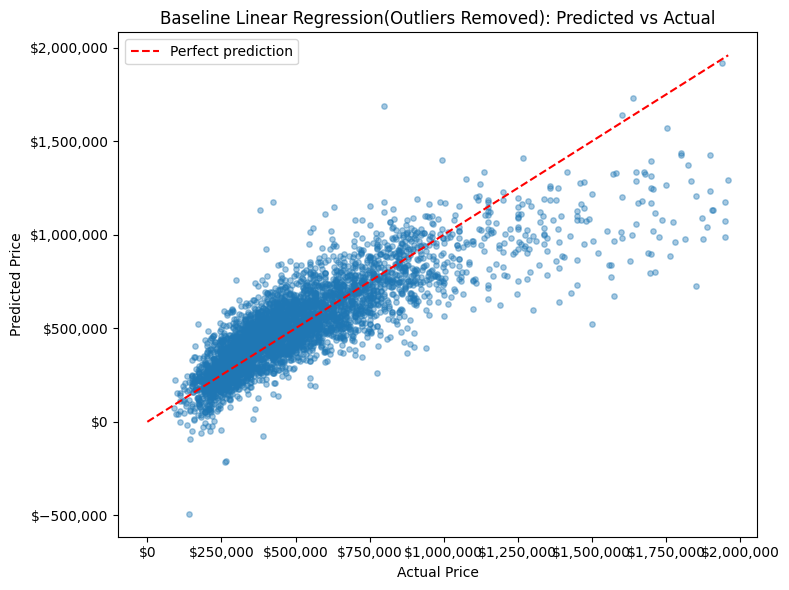

In [24]:
#Filter: Drop the extremely expensive houses
df3_outr = df3_outr[df3_outr['price'] < 2500000]


# Scale numerical features
scaler = StandardScaler()
df3_outr[numerical_features] = scaler.fit_transform(df3_outr[numerical_features])

# One-Hot Encodes all categorical data
categorical_cols_to_encode = df3_outr.select_dtypes(include='object').columns
df3_outr = pd.get_dummies(df3_outr, columns=categorical_cols_to_encode, drop_first=True)

#Extracting Features
target_column = 'price'
features = [col for col in df3_outr.columns if col != target_column]

#Creating "X" and "Y"
x_g = df3_outr[features].copy()
y_g = df3_outr[target_column].copy()

#Creating split
x_train_g, x_test_g, y_train_g, y_test_g = train_test_split(x_g, y_g, test_size=0.2, random_state=42)

#Creating Model
model_1 = LinearRegression()
model_1.fit(x_train_g, y_train_g)
predictions = model_1.predict(x_test_g)

#Printing Metrics
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_g, predictions):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test_g, predictions):,.2f}")
print(f"r2: {metrics.r2_score(y_test_g, predictions):.4f}")

#Cross Validated Metrics
print(f"\nCross-validation RMSE:\t${-cross_val_score(model_1, x_g, y_g, cv=5, scoring='neg_root_mean_squared_error').mean():,.2f}")
print(f"Cross-validation MAE:\t${-cross_val_score(model_1, x_g, y_g, cv=5, scoring='neg_mean_absolute_error').mean():,.2f}")
print(f"Cross-validation R²:\t{cross_val_score(model_1, x_g, y_g, cv=5, scoring='r2').mean():.4f}")

#Plotting Curve of Prediction vs Actual to show the accuracy 
plt.figure(figsize=(8, 6))
plt.scatter(y_test_g, predictions, alpha=0.4, s=15)
max_val = max(y_test_g.max(), predictions.max()) 
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price') 
plt.ylabel('Predicted Price')
plt.title('Baseline Linear Regression(Outliers Removed): Predicted vs Actual')
plt.legend()
ax = plt.gca() 
import matplotlib.ticker as ticker # Ensure ticker is imported
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.tight_layout()  
plt.show()

This model is more in line with what you'd expect from a well constructed linear model the measures of varaince and graphs are all within acceptable parameters. You could make the model even more accurate by getting rid of the cluster past 2 million this would yield a model closer to 75% however culling good data is generally bad practice in Machine Learning/Data Science.

### Further Analyisis of the Model with the Outliers Removed

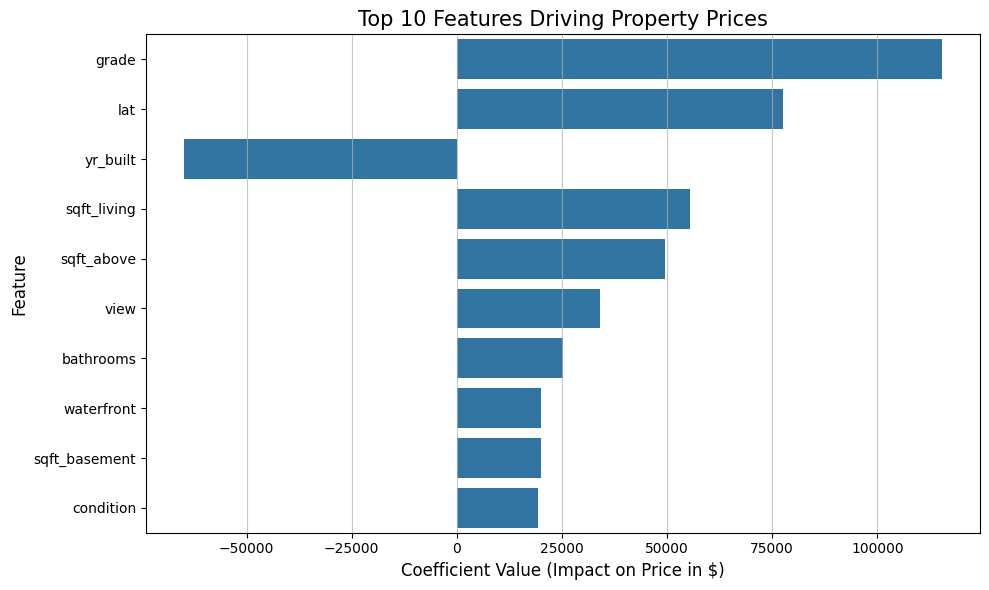

,Feature,Coefficient
8,grade,115418.343859
12,lat,77690.411529
11,yr_built,-64935.203954
2,sqft_living,55524.980632
9,sqft_above,49565.185761
6,view,33981.658257
1,bathrooms,25326.839950
5,waterfront,19969.557695
10,sqft_basement,19967.802430
7,condition,19341.804907


In [25]:
import seaborn as sns
#Fetching Feature Names and Coefficents
feature_names = x_train_g.columns
coefficients = model_1.coef_

#Wrapping them together in a Pandas DataFrame for Easy Comparision and Viewing
feature_importance = pd.DataFrame({
 'Feature': feature_names,
 'Coefficient': coefficients
})

#Using the Absolute Function in the NumPy Library before Sorting the Coefficents in Decending Order
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
top_10_features = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
sns.barplot(
 data=top_10_features, 
 x='Coefficient', 
 y='Feature', 
)

#Graph of the Top 10 features
plt.title('Top 10 Features Driving Property Prices', fontsize=15)
plt.xlabel('Coefficient Value (Impact on Price in $)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()
display(top_10_features[['Feature', 'Coefficient']])

Based on the graph, 'year built' and 'number of bedrooms' serve as our primary negative predictors. Older homes appear to command a premium over newer ones, likely because they are typically sold by individuals or traditional real estate agents. This contrasts with large private investors, who are often incentivized to sell at or below market rates to secure quick returns on their investments.

However, the most interesting feature is the number of bedrooms. Intuitively, one would expect houses with more bedrooms to be more valuable. The most likely explanation for this negative correlation is that the data is tightly clustered between $100k and $1 million, with a dataset cutoff at $2.5 million. Because most houses in these price ranges have a similar number of bedrooms, the feature may have become coupled with other negative predictors, such as 'year built.' Modern houses tend to forgo a fourth bedroom, whether due to a trend toward larger shared living spaces or the needs of smaller families. Furthermore, the removal of mansions from the dataset eliminated the massive 12+ bedroom properties that would have significantly shifted how this feature was weighted.

The positive predictors are more conventional: large, modern, and well-constructed houses on expansive plots with extra amenities outperform those without. Notably, the build quality appears to vastly outweigh the sheer size of the house or the land it occupies.

## Log Scaled Model Features Evaulation

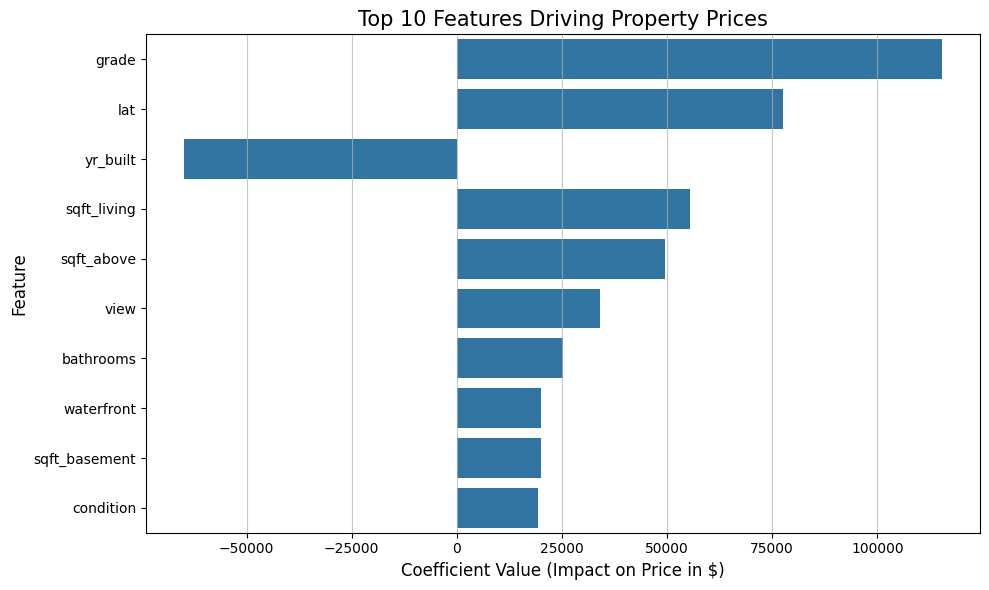

,Feature,Coefficient
8,grade,115418.343859
12,lat,77690.411529
11,yr_built,-64935.203954
2,sqft_living,55524.980632
9,sqft_above,49565.185761
6,view,33981.658257
1,bathrooms,25326.839950
5,waterfront,19969.557695
10,sqft_basement,19967.802430
7,condition,19341.804907


In [26]:
#Fetching Feature Names and Coefficents
feature_names = x_train.columns
coefficients = model_1.coef_

#Wrapping them together in a Pandas DataFrame for Easy Comparision and Viewing
feature_importance = pd.DataFrame({
 'Feature': feature_names,
 'Coefficient': coefficients
})

#Using the Absolute Function in the NumPy Library before Sorting the Coefficents in Decending Order
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
top_10_features = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
sns.barplot(
 data=top_10_features, 
 x='Coefficient', 
 y='Feature', 
)
#Graph of the Top 10 features
plt.title('Top 10 Features Driving Property Prices', fontsize=15)
plt.xlabel('Coefficient Value (Impact on Price in $)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()
display(top_10_features[['Feature', 'Coefficient']])


-Since X was not log scaled the analysis from Previously applies

## Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest... This may take a moment depending on dataset size.")
rf_model.fit(x_train, y_train)

# Generate predictions on the log-scaled test set
rf_predictions = rf_model.predict(x_test)


#Generate Cross Validation Metrics in Log Space
print("\n--- Log-Space Metrics (Random Forest) ---")
print(f"RMSE: {metrics.root_mean_squared_error(y_test, rf_predictions):.4f}")
print(f"MAE:  {metrics.mean_absolute_error(y_test, rf_predictions):.4f}")
print(f"R²:   {metrics.r2_score(y_test, rf_predictions):.4f}\n")

print(f"\nCross-validation RMSE:\t{-cross_val_score(rf_model, x, y, cv=5, scoring='neg_root_mean_squared_error').mean():,.2f}")
print(f"Cross-validation MAE:\t{-cross_val_score(rf_model, x, y, cv=5, scoring='neg_mean_absolute_error').mean():,.2f}")
print(f"Cross-validation R²:\t{cross_val_score(rf_model, x, y, cv=5, scoring='r2').mean():.4f}")

#Real Space Metrics
y_test_real = np.expm1(y_test)
rf_predictions_real = np.expm1(rf_predictions)

print("--- Real-Space (Dollar) $ Metrics (Random Forest) ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_real, rf_predictions_real):,.2f}")
print(f"MAE:  ${metrics.mean_absolute_error(y_test_real, rf_predictions_real):,.2f}")
print(f"R²:   {metrics.r2_score(y_test_real, rf_predictions_real):.4f}\n")

# Cross Validation for the RF model
cv_results = cross_validate(rf_model, x, y, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")




Training Random Forest... This may take a moment depending on dataset size.

--- Log-Space Metrics (Random Forest) ---
RMSE: 0.1781
MAE:  0.1270
R²:   0.8888


Cross-validation RMSE:	0.18
Cross-validation MAE:	0.13
Cross-validation R²:	0.8872
--- Real-Space (Dollar) $ Metrics (Random Forest) ---
RMSE: $138,230.34
MAE:  $72,378.22
R²:   0.8736

--- Cross Validated Scores ---
RMSE: $135,173.23
MAE: $70,584.26
r2: 0.8638



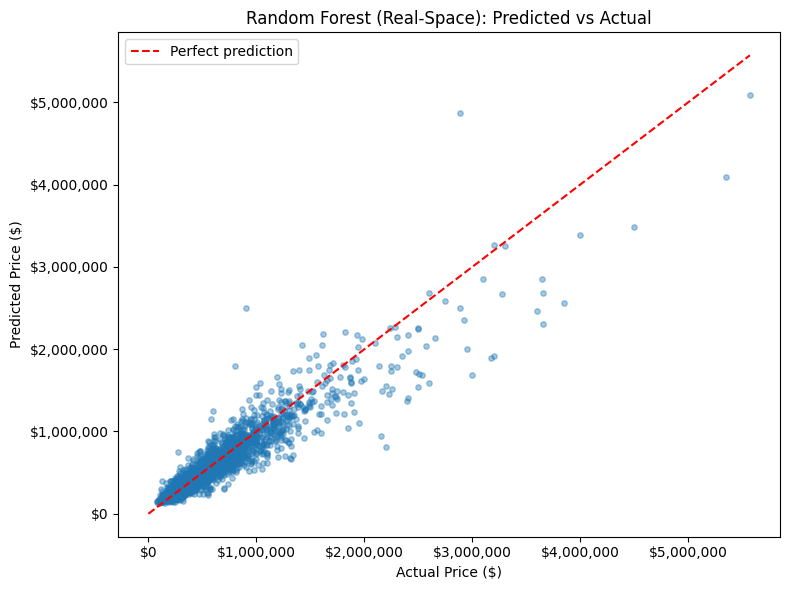

In [28]:
#Real-Space Graph
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(y_test_real, rf_predictions_real, alpha=0.4, s=15)
max_val_real = max(y_test_real.max(), rf_predictions_real.max())
ax2.plot([0, max_val_real], [0, max_val_real], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual Price ($)') 
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Random Forest (Real-Space): Predicted vs Actual')
ax2.legend()
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

Combining a log-scale transformation with a model that assumes unequal variances yields a model that significantly outperforms both previous linear models. Improvements of over 25% are evident across all key metrics, including MAE, RMSE, and R-squared. Consequently, there is no need to generate a separate model, as this unified approach provides consistent accuracy across the entire dataset

### Analyisis of Feature Importance for The Random Forest Model

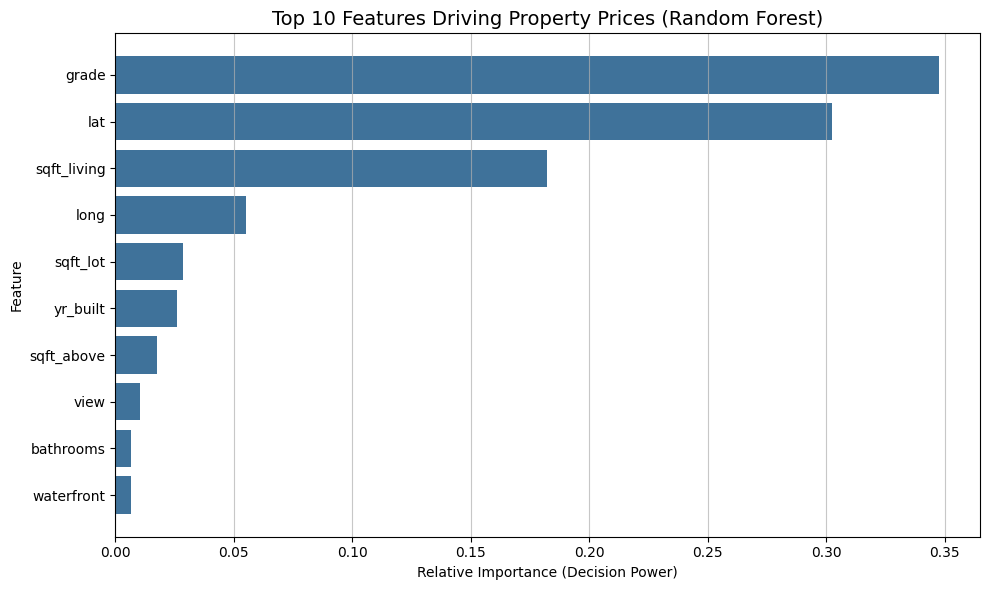

In [29]:

#Extract the feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = x_train.columns
feature_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

#Sorting By importance
top_10_features = feature_df.sort_values(by='Importance', ascending=True).tail(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='#3f729a') 
plt.xlabel('Relative Importance (Decision Power)')
plt.ylabel('Feature')
plt.title('Top 10 Features Driving Property Prices (Random Forest)', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.7) 
plt.tight_layout()
plt.show()



Including the outliers which caused most of the issues in the previous model slightly altered the importance ranking of the top 10 features. Firstly, the number of bedrooms is no longer as strong a predictor, which was expected. Although there is a trend toward building fewer new houses with four or more bedrooms, the inclusion of mansions (12+ bedrooms) with valuations that massively exceed typical homes made the model less willing to rely on bedroom count as a strong negative predictor, assuming it remains a negative predictor at all. (This reflects one of the inherent limitations of the Random Forest model.)

Another notable shift is that longitude is now a top-five predictor, whereas it did not even rank in the top 10 for the linear model. Previously, the model determined that properties located further north were more valuable. This might be driven by a general pattern of wealth and class stratification in the northern regions of Western areas like the US and Europe; for example, New York City boasts much higher salaries and housing prices than Oklahoma. The current model, however, weighs both spatial coordinates more equally, though it still slightly favors latitude over longitude

## Tweaked Random Forest 

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from scipy.stats import randint, uniform


rf_model = RandomForestRegressor(random_state=42)


param_distributions = {
    'n_estimators': randint(10, 500),      
    'max_depth': randint(1, 20),          
    'min_samples_split': uniform(0.01, 0.2),
    'min_samples_leaf': randint(1, 10),      
    'max_features': uniform(0, 1)        
}

rf_random = RandomizedSearchCV(
    estimator=rf_model, 
    param_distributions=param_distributions, 
    n_iter=300,                           
    cv=5,      
    scoring= scoring_dict,  
    refit= 'rmse',             
    random_state=42
)


rf_random.fit(x_train, y_train)
print("Best Parameters:", rf_random.best_params_)

rf_predictions = rf_random.predict(x_test)
y_test_real = np.expm1(y_test)
rf_predictions_real = np.expm1(rf_predictions)

Best Parameters: {'max_depth': 8, 'max_features': np.float64(0.6181282404578958), 'min_samples_leaf': 8, 'min_samples_split': np.float64(0.014436948406060326), 'n_estimators': 259}


In [32]:
#Printing Values
print("--- Real-Space (Dollar) $ Metrics (Random Forest) ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_real, rf_predictions_real):,.2f}")
print(f"MAE:  ${metrics.mean_absolute_error(y_test_real, rf_predictions_real):,.2f}")
print(f"R²:   {metrics.r2_score(y_test_real, rf_predictions_real):.4f}\n")

--- Real-Space (Dollar) $ Metrics (Random Forest) ---
RMSE: $203,184.22
MAE:  $95,647.25
R²:   0.7269



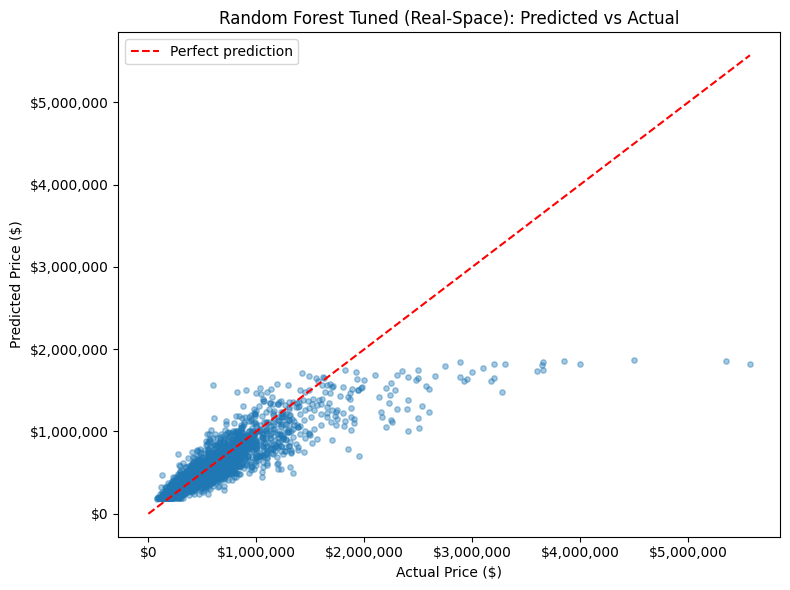

In [33]:
#Graph for tuned RF
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(y_test_real, rf_predictions_real, alpha=0.4, s=15)
max_val_real = max(y_test_real.max(), rf_predictions_real.max())
ax2.plot([0, max_val_real], [0, max_val_real], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual Price ($)') 
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Random Forest Tuned (Real-Space): Predicted vs Actual')
ax2.legend()
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

This model was tuned to reduce the variance as much as possible by using the rmse as the final decider on which parameter would be selected. Oddly enough the final model performed worse in evry metric. This is due to the optimal nature of the default settings. Atleast for this data set it is not worth the computational work to tune a random forest model over just uisng default settings. 

The model produced was very conservative in guessing the prices of tending to stick with guess under 2 million causing a reduction in accuracy and variance.

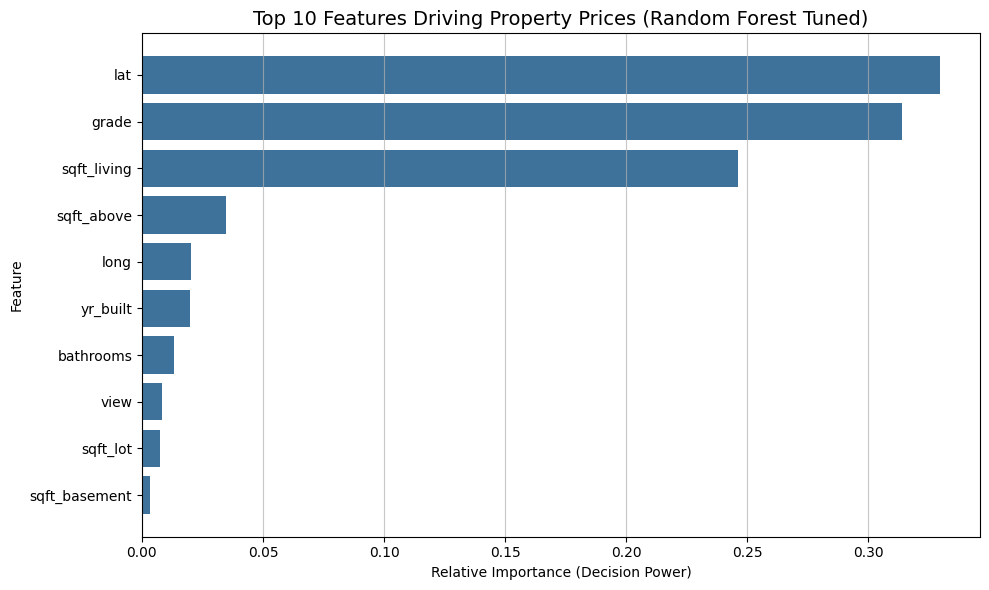

In [34]:
#Extract the feature importances from the Random Forest model
rf_model = rf_random.best_estimator_
importances = rf_model.feature_importances_
feature_names = x_train.columns
feature_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

#Sorting By importance
top_10_features = feature_df.sort_values(by='Importance', ascending=True).tail(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='#3f729a') 
plt.xlabel('Relative Importance (Decision Power)')
plt.ylabel('Feature')
plt.title('Top 10 Features Driving Property Prices (Random Forest Tuned)', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.7) 
plt.tight_layout()
plt.show()



In trying to reduce the variance the model reduced the importance of longitude and relied almost entirely on the square footage of the house, the latitude and the grade or quality of the construction. This was most likely due to an overeliance on the cheaper housing as data points and ignoring the few expensive houses.